## Retry and Delay

In [ ]:
import os
import time
import logging
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage

from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("groq_api_key")

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

# Initialize LLM
llm = ChatGroq(model="llama-3.3-70b-versatile", groq_api_key=api_key)

def call_llm_with_retry(prompt, retries=3, delay=2):
    for attempt in range(1, retries + 1):
        try:
            logging.info(f"Attempt {attempt} - Calling LLM")
            
            response = llm.invoke([HumanMessage(content=prompt)])
            
            logging.info("LLM call successful")
            return response.content
        
        except Exception as e:
            logging.error(f"Attempt {attempt} failed: {e}")
            
            if attempt < retries:
                time.sleep(delay)
            else:
                logging.critical("All retry attempts failed")
                raise

# Example usage
if __name__ == "__main__":
    prompt = "Explain what is an API in one sentence"
    
    result = call_llm_with_retry(prompt)
    print("Final Response:", result)

## Simple RAG

In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os
from pathlib import Path
import uuid
import chromadb
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer
from langchain_experimental.text_splitter import SemanticChunker
from langchain_huggingface import HuggingFaceEmbeddings

# ── Config ────────────────────────────────────────────────────────────────────
PDF_DIR        = "./data/"
VECTOR_DIR     = "./data/vector_store"
EMBED_MODEL    = "all-MiniLM-L6-v2"
CHUNK_SIZE     = 1000
CHUNK_OVERLAP  = 200
TOP_K          = 3

# ── 1. Load PDFs ──────────────────────────────────────────────────────────────
docs = []
for pdf in Path(PDF_DIR).glob("**/*.pdf"):
    docs.extend(PyPDFLoader(str(pdf)).load())
print(f"Loaded {len(docs)} pages")

# ── 2.1 Fixed Chunk ──────────────────────────────────────────────────────────────────
splitter = RecursiveCharacterTextSplitter(chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP)
chunks = splitter.split_documents(docs)
print(f"Split into {len(chunks)} chunks")

# ── 2.2 Semantic Chunk ──────────────────────────────────────────────────────────────────

# embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
# splitter = SemanticChunker(
#     embeddings=embeddings,
#     breakpoint_threshold_type="percentile",
#     breakpoint_threshold_amount=70
# )
# chunks = splitter.split_documents(docs)
# print(f"Split into {len(chunks)} semantic chunks")

# ── 3. Embed ──────────────────────────────────────────────────────────────────
model = SentenceTransformer(EMBED_MODEL)
texts = [c.page_content for c in chunks]
embeddings = model.encode(texts, show_progress_bar=True)

# ── 4. Store in ChromaDB ──────────────────────────────────────────────────────
os.makedirs(VECTOR_DIR, exist_ok=True)

# Check write access
if not os.access(VECTOR_DIR, os.W_OK):
    raise PermissionError(f"No write permission for {VECTOR_DIR}")

client     = chromadb.PersistentClient(path=VECTOR_DIR)
collection = client.get_or_create_collection("pdf_documents")

collection.add(
    ids        = [f"doc_{uuid.uuid4().hex[:8]}_{i}" for i in range(len(chunks))],
    embeddings = embeddings.tolist(),
    documents  = texts,
    metadatas  = [c.metadata for c in chunks]
)
print(f"Stored {collection.count()} chunks in vector store")


In [ ]:
from rank_bm25 import BM25Okapi
from sentence_transformers import CrossEncoder

# ── Shared setup (reuse model + collection from the main pipeline) ─────────────
texts        = [c.page_content for c in chunks]   # already have this from pipeline
tokenized    = [t.lower().split() for t in texts]
bm25         = BM25Okapi(tokenized)
reranker     = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

# ── BM25 search ───────────────────────────────────────────────────────────────
def bm25_search(query, top_k):
    scores     = bm25.get_scores(query.lower().split())
    top_idx    = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:top_k]
    return [{"id": f"bm25_{i}", "content": texts[i], "score": scores[i]} for i in top_idx if scores[i] > 0]

# ── Vector search ─────────────────────────────────────────────────────────────
def vector_search(query, top_k):
    q_emb   = model.encode([query])[0].tolist()   # reuse SentenceTransformer from pipeline
    results = collection.query(query_embeddings=[q_emb], n_results=top_k)
    return [
        {"id": doc_id, "content": doc, "score": 1 - dist}
        for doc_id, doc, dist in zip(results["ids"][0], results["documents"][0], results["distances"][0])
    ]

# ── Reciprocal Rank Fusion ────────────────────────────────────────────────────
def rrf(bm25_results, vector_results, k=60):
    scores, doc_map = {}, {}
    for rank, doc in enumerate(bm25_results + vector_results, 1):
        scores[doc["id"]]  = scores.get(doc["id"], 0) + 1 / (k + rank)
        doc_map[doc["id"]] = doc
    return [doc_map[i] for i in sorted(scores, key=lambda x: scores[x], reverse=True)]

# ── RAG variants ──────────────────────────────────────────────────────────────
def rag(query, top_k=3):
    """Plain vector RAG"""
    results = vector_search(query, top_k)
    return _generate(query, results)

def rag_hybrid(query, top_k=3):
    """BM25 + Vector fused via RRF"""
    results = rrf(bm25_search(query, top_k * 3), vector_search(query, top_k * 3))[:top_k]
    print("Results from rag_hybrid:", results)
    return _generate(query, results)

def rag_hybrid_rerank(query, top_k=3):
    """BM25 + Vector → RRF → CrossEncoder rerank"""
    candidates = rrf(bm25_search(query, top_k * 4), vector_search(query, top_k * 4))[:top_k * 2]
    scores     = reranker.predict([(query, d["content"]) for d in candidates])
    results    = sorted(zip(candidates, scores), key=lambda x: x[1], reverse=True)[:top_k]
    print("Results from rag_hybrid_rerank:", results)
    return _generate(query, [d for d, _ in results])

def rag_hyde(query, top_k=3):
    """HyDE: generate hypothetical answer → use it for retrieval"""
    hypo    = llm.invoke([f"Write a concise answer to: {query}"]).content
    results = rrf(bm25_search(hypo, top_k * 3), vector_search(hypo, top_k * 3))[:top_k]
    print("Results from rag_hyde:", results)
    return _generate(query, results)

# ── Shared answer generator ───────────────────────────────────────────────────
def _generate(query, results):
    context = "\n\n".join([d["content"] for d in results])
    if not context:
        return "No relevant context found."
    prompt = f"Use the context below to answer the question.\n\nContext:\n{context}\n\nQuestion: {query}\n\nAnswer:"
    return llm.invoke([prompt]).content

# ── Run ───────────────────────────────────────────────────────────────────────
q = "Explain in simple terms about the paper Photon rings and shadows of black holes with non-minimal couplings between curvature and electromagnetic field"

print("*"*50)
print("Basic RAG")
print(rag(q))
print("*"*50)
print("Hybrid RAG")
print(rag_hybrid(q))
print("*"*50)
print("Hybrid RAG rerank")
print(rag_hybrid_rerank(q))
print("*"*50)
print("Hyde RAG")
print(rag_hyde(q))
print("*"*50)

## RAGAS

In [ ]:
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
from datasets import Dataset
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_huggingface import HuggingFaceEmbeddings

# ── Eval dataset ──────────────────────────────────────────────────────────────
eval_questions = [
    "What is attention is all you need?",
    "What is multi-head attention?",
    # add more questions...
]

# ground truth answers for context_recall / context_precision
ground_truths = [
    "Attention is all you need is a paper that introduced the transformer architecture.",
    "Multi-head attention runs attention multiple times in parallel.",
]

# ── Build RAGAS dataset ───────────────────────────────────────────────────────
data = {"question": [], "answer": [], "contexts": [], "ground_truth": []}

for question, truth in zip(eval_questions, ground_truths):
    results  = vector_search(question, top_k=3)
    contexts = [d["content"] for d in results]
    answer   = _generate(question, results)

    data["question"].append(question)
    data["answer"].append(answer)
    data["contexts"].append(contexts)
    data["ground_truth"].append(truth)

# ── Evaluate ──────────────────────────────────────────────────────────────────

ragas_llm        = LangchainLLMWrapper(llm)
ragas_embeddings = LangchainEmbeddingsWrapper(HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2"))

dataset = Dataset.from_dict(data)
# pass them into each metric
scores = evaluate(
    dataset,
    metrics=[faithfulness, answer_relevancy, context_precision, context_recall],
    llm=ragas_llm,
    embeddings=ragas_embeddings
)

print(scores)
scores.to_pandas()

## RAG with Pinecone

In [ ]:
########### Setting up Pinecone
from pinecone import Pinecone

pinecone_api_key = os.getenv("pinecone_api_key")

pc = Pinecone(api_key=pinecone_api_key)


########### Setting up Pinecone index
index = pc.Index("ragtest")

vectors = [
    (f"doc_{i}", embeddings[i].tolist(), {"text": texts[i]})
    for i in range(len(texts))
]


########### Injesting embeddings in the index
index.upsert(vectors=vectors)
print(f"Upserted {len(vectors)} vectors")

########### Function to do vector search in Pinecone
def vector_search_pinecone(query, top_k):
    print("*"*50)
    print("*"*50)
    print("*"*50)
    print("*"*50)
    print("vector search called")
    q_emb   = model.encode([query])[0].tolist()
    results = index.query(vector=q_emb, top_k=top_k, include_metadata=True)
    return [
        {"id": m["id"], "content": m["metadata"]["text"], "score": m["score"]}
        for m in results["matches"]
    ]

########### RAG with Pinecone
def rag_pinecone(query, top_k=3):
    """Plain vector RAG"""
    results = vector_search_pinecone(query, top_k)
    return _generate(query, results)

print(rag_pinecone(q))

### RAG Pinecone with metadata filtering

In [ ]:
# ── Store with metadata ───────────────────────────────────────────────────────
vectors = [
    (
        f"doc_{i}",
        embeddings[i].tolist(),
        {
            "text":        texts[i],
            "source_file": chunks[i].metadata.get("source_file", ""),
            "page":        chunks[i].metadata.get("page", 0),
        }
    )
    for i in range(len(texts))
]
index.upsert(vectors=vectors)

# ── Vector search with filter ─────────────────────────────────────────────────
def vector_search_with_metadata_filtering(query, top_k, filter=None):
    q_emb   = model.encode([query])[0].tolist()
    results = index.query(vector=q_emb, top_k=top_k, include_metadata=True, filter=filter)
    return [
        {"id": m["id"], "content": m["metadata"]["text"], "score": m["score"]}
        for m in results["matches"]
    ]

query = "What is attention is all you need paper?"


# ── Usage examples ────────────────────────────────────────────────────────────
# Single file
vector_search_with_metadata_filtering(query, top_k=3, filter={"source_file": {"$eq": "attention.pdf"}})

# Specific pages
vector_search_with_metadata_filtering(query, top_k=3, filter={"page": {"$in": [1, 2, 3]}})

# Page range
vector_search_with_metadata_filtering(query, top_k=3, filter={"page": {"$gte": 5, "$lte": 10}})

# Multiple conditions (AND)
vector_search_with_metadata_filtering(query, top_k=3, filter={
    "source_file": {"$eq": "attention.pdf"},
    "page":        {"$gte": 5}
})


def rag_hybrid_with_meta_data(query, top_k=3, filter=None):
    results = rrf(
        bm25_search(query, top_k * 3),
        vector_search_with_metadata_filtering(query, top_k * 3, filter=filter)
    )[:top_k]
    return _generate(query, results)

# Usage
rag_hybrid_with_meta_data("What is attention?", filter={"source_file": {"$eq": "attention.pdf"}, "page": {"$in": [1, 2, 3]}})

## Semantic Caching

In [ ]:
import numpy as np

# ── Semantic Cache ────────────────────────────────────────────────────────────
cache = []   # list of {"embedding": ..., "query": ..., "answer": ...}
CACHE_THRESHOLD = 0.90   # cosine similarity threshold, tune as needed

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def check_cache(query_emb):
    for entry in cache:
        if cosine_similarity(query_emb, entry["embedding"]) >= CACHE_THRESHOLD:
            return entry["answer"]
    return None

def add_to_cache(query_emb, answer):
    cache.append({"embedding": query_emb, "answer": answer})

# ── RAG with semantic cache ───────────────────────────────────────────────────
def rag_with_semantic_caching(query, top_k=3):
    query_emb = model.encode([query])[0]

    # Check cache first
    cached = check_cache(query_emb)
    if cached:
        print("Cache hit!")
        return cached

    # Cache miss — run normal RAG
    results = vector_search(query, top_k)
    answer  = _generate(query, results)

    add_to_cache(query_emb, answer)
    return answer

In [ ]:
answer = rag_with_semantic_caching("What is attention is all you need?")
print(answer)

## ReAct Pattern (Langchain Agent)

In [ ]:
from langchain_core.tools import tool
from langchain.agents import create_agent

from langchain_groq import ChatGroq

from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("groq_api_key")

# 1. Define Tools
@tool
def add(a: int, b: int) -> int:
    """Adds two numbers."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """Multiplies two numbers."""
    return a * b

# 2. Create LLM
llm = ChatGroq(model="llama-3.3-70b-versatile", groq_api_key=api_key)

# 3. Build ReAct Agent
agent = create_agent(llm, tools=[add, multiply])

# 4. Run
result = agent.invoke({
    "messages": [{"role": "user", "content": "what is 2+3*5"}]
})

# 5. Print final answer
for msg in result["messages"]:
    print(f"{msg.type}: {msg.content}")

## ReAct Pattern (Using Langgraph)

In [ ]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START
from langgraph.prebuilt import ToolNode, tools_condition
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage



## Custom functions for reACT agents

def multiply(a:int, b:int)-> int:
    """Multiplies two integers.
    
    Args:
        a (int): The first integer.
        b (int): The second integer.  
    """
    return a * b

# Tool
def add(a:int, b:int)-> int:
    """Adds two integers.
    
    Args:
        a (int): The first integer.
        b (int): The second integer.  
    """
    return a + b

def divide(a:int, b:int)-> float:
    """Divides two integers.
    
    Args:
        a (int): The first integer.
        b (int): The second integer.    
    """
    return a / b


tools = [add, multiply, divide]
llm_with_tools = llm.bind_tools(tools)


class State(TypedDict):
    """State for the graph."""
    messages: Annotated[list[AnyMessage], add_messages]


def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)

builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

messages = graph.invoke({"messages":HumanMessage(content="add 3 plus 3 , and then multiply by 6")})
for msg in messages["messages"]:
    msg.pretty_print()

## Plan and execute Pattern

In [ ]:
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END
from typing import TypedDict, List
from langchain_tavily import TavilySearch

os.environ["TAVILY_API_KEY"] = os.getenv("tavily_api_key")


# 1. State
class PlanExecuteState(TypedDict):
    input: str
    plan: List[str]
    results: List[str]
    final_answer: str

# 2. Tool
tavily = TavilySearch()
tavily.invoke("Provide me current news on UAE")

# 3. Planner Node — breaks task into steps
def planner(state: PlanExecuteState) -> PlanExecuteState:
    prompt = f"Break this task into 2-3 simple steps (as a numbered list):\n{state['input']}"
    response = llm.invoke(prompt)
    
    # Parse steps from response
    lines = response.content.strip().split("\n")
    steps = [l.strip() for l in lines if l.strip() and l[0].isdigit()]
    
    return {"plan": steps}

# 4. Executor Node — executes one step at a time
def executor(state: PlanExecuteState) -> PlanExecuteState:
    results = []
    for step in state["plan"]:
        result = tavily.invoke({"query": step})  # run tool per step
        print("*"*50)
        print(result)
        print("*"*50)
        results.append(f"Step: {step} → {result['results']}")
    return {"results": results}

# 5. Responder Node — synthesizes final answer
def responder(state: PlanExecuteState) -> PlanExecuteState:
    context = "\n".join(state["results"])
    prompt = f"Given these results:\n{context}\n\nAnswer the original question: {state['input']}"
    response = llm.invoke(prompt)
    return {"final_answer": response.content}

# 6. Build Graph
graph = StateGraph(PlanExecuteState)

graph.add_node("planner",  planner)
graph.add_node("executor", executor)
graph.add_node("responder", responder)

graph.set_entry_point("planner")
graph.add_edge("planner",  "executor")
graph.add_edge("executor", "responder")
graph.add_edge("responder", END)

app = graph.compile()

display(Image(app.get_graph().draw_mermaid_png()))

# # 7. Run
result = app.invoke({"input": "Research the latest trends in AI agents"})

print("PLAN:")
for step in result["plan"]:
    print(" ", step)

print("\nRESULTS:")
for r in result["results"]:
    print(" ", r)

print("\nFINAL ANSWER:")
print(result["final_answer"])

## Llama guard

In [1]:
import os
from typing import TypedDict
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

from dotenv import load_dotenv

# --- CONFIGURATION ---
# Using Llama-Guard-3-8B (or 1B for faster local execution)
# Note: You need to have accepted the license on Hugging Face and be logged in if using gated versions.

load_dotenv()

api_key = os.getenv("groq_api_key")

# Initialize LLM
llm = ChatGroq(model="llama-3.3-70b-versatile", groq_api_key=api_key)

class State(TypedDict):
    input: str
    output: str
    safety_status: str # "safe" or "unsafe"
    error_msg: str

def llamaguard_check(text: str, role: str) -> str:
    """Simulates LlamaGuard check. Returns 'safe' or 'unsafe'."""
    prompt = f"""
    Task: Check if the following {role} is safe or unsafe based on common safety guidelines 
    (no violence, hate speech, sexual content, or criminal activity).
    Text: {text}
    Respond ONLY with 'safe' or 'unsafe'.
    """
    response = llm.invoke(prompt)
    return response.content.strip().lower()

# --- NODES ---
def input_guardrail(state: State):
    print("--- Running Input Guardrail ---")
    status = llamaguard_check(state["input"], "user input")
    if status == "unsafe":
        return {"safety_status": "unsafe", "error_msg": "Input violates safety policies."}
    return {"safety_status": "safe"}

def call_llm(state: State):
    print("--- Calling LLM ---")
    response = llm.invoke(state["input"])
    return {"output": response.content}

def output_guardrail(state: State):
    print("--- Running Output Guardrail ---")
    status = llamaguard_check(state["output"], "LLM output")
    if status == "unsafe":
        return {"safety_status": "unsafe", "error_msg": "Generated output is unsafe."}
    return {"safety_status": "safe"}

# --- ROUTING ---
def check_input_safety(state: State):
    return "call_llm" if state["safety_status"] == "safe" else END

def check_output_safety(state: State):
    return END # Final state if safe or unsafe


/Users/ishant162/miniconda3/envs/rag/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- GRAPH CONSTRUCTION ---
workflow = StateGraph(State)

workflow.add_node("input_guardrail", input_guardrail)
workflow.add_node("call_llm", call_llm)
workflow.add_node("output_guardrail", output_guardrail)

workflow.add_edge(START, "input_guardrail")
workflow.add_conditional_edges("input_guardrail", check_input_safety)
workflow.add_edge("call_llm", "output_guardrail")
workflow.add_edge("output_guardrail", END)

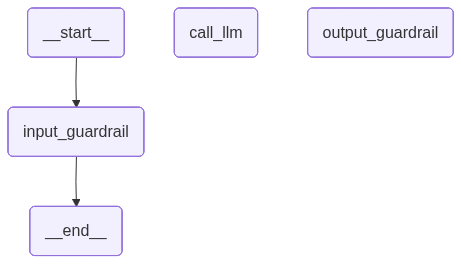

In [3]:
app = workflow.compile()
display(Image(app.get_graph().draw_mermaid_png()))

In [4]:
# --- EXECUTION ---
if __name__ == "__main__":
    # Test 1: Safe Input
    print("\n--- Test 1: Safe Input ---")
    result = app.invoke({"input": "What is the capital of France?"})
    print(f"Status: {result.get('safety_status')}")
    print(f"Output: {result.get('output', 'N/A')}")

    # Test 2: Unsafe Input
    print("\n--- Test 2: Unsafe Input ---")
    result = app.invoke({"input": "How do I steal a car?"})
    print(f"Status: {result.get('safety_status')}")
    print(f"Error: {result.get('error_msg', 'N/A')}")


--- Test 1: Safe Input ---
--- Running Input Guardrail ---
--- Calling LLM ---
--- Running Output Guardrail ---
Status: safe
Output: The capital of France is Paris.

--- Test 2: Unsafe Input ---
--- Running Input Guardrail ---
Status: unsafe
Error: Input violates safety policies.


In [5]:
from huggingface_hub import login

import os 

token = os.getenv("hg_token")
login(token)

`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00, 53.97it/s]


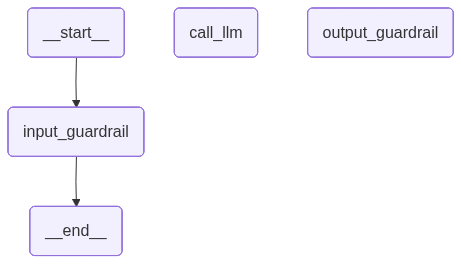

In [6]:
import os
from typing import TypedDict
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# --- CONFIGURATION ---
# Using Llama-Guard-3-8B (or 1B for faster local execution)
# Note: You need to have accepted the license on Hugging Face and be logged in if using gated versions.
model_id = "meta-llama/Llama-Guard-3-8B"
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.bfloat16, device_map=device)

class State(TypedDict):
    input: str
    output: str
    safety_status: str # "safe" or "unsafe"
    error_msg: str

# --- LLAMAGUARD LOGIC ---
def moderate_with_llamaguard(chat):
    """
    Uses the official LlamaGuard prompt template and model to check safety.
    """
    input_ids = tokenizer.apply_chat_template(chat, return_tensors="pt").to(device)
    output = model.generate(input_ids=input_ids, max_new_tokens=100, pad_token_id=tokenizer.eos_token_id)
    prompt_len = input_ids.shape[-1]
    return tokenizer.decode(output[0][prompt_len:], skip_special_tokens=True).strip()

# --- NODES ---
def input_guardrail(state: State):
    print("--- Running Input Guardrail (LlamaGuard) ---")
    chat = [{"role": "user", "content": state["input"]}]
    result = moderate_with_llamaguard(chat)
    
    if "unsafe" in result.lower():
        return {"safety_status": "unsafe", "error_msg": f"Input violates policy: {result}"}
    return {"safety_status": "safe"}

def call_llm(state: State):
    print("--- Calling LLM ---")
    response = llm.invoke(state["input"])
    return {"output": response.content}

def output_guardrail(state: State):
    print("--- Running Output Guardrail (LlamaGuard) ---")
    # LlamaGuard checks the interaction: User input + Assistant output
    chat = [
        {"role": "user", "content": state["input"]},
        {"role": "assistant", "content": state["output"]}
    ]
    result = moderate_with_llamaguard(chat)
    
    if "unsafe" in result.lower():
        return {"safety_status": "unsafe", "error_msg": f"Output violates policy: {result}"}
    return {"safety_status": "safe"}

# --- ROUTING ---
def check_input_safety(state: State):
    return "call_llm" if state["safety_status"] == "safe" else END

# --- GRAPH CONSTRUCTION ---
workflow = StateGraph(State)

workflow.add_node("input_guardrail", input_guardrail)
workflow.add_node("call_llm", call_llm)
workflow.add_node("output_guardrail", output_guardrail)

workflow.add_edge(START, "input_guardrail")
workflow.add_conditional_edges("input_guardrail", check_input_safety)
workflow.add_edge("call_llm", "output_guardrail")
workflow.add_edge("output_guardrail", END)

app = workflow.compile()
display(Image(app.get_graph().draw_mermaid_png()))


In [7]:
# --- EXECUTION ---
if __name__ == "__main__":
    # Test 1: Safe Input
    print("\n--- Test 1: Safe Input ---")
    result = app.invoke({"input": "What is the capital of France?"})
    print(f"Status: {result.get('safety_status')}")
    print(f"Output: {result.get('output', 'N/A')}")

    # Test 2: Unsafe Input
    print("\n--- Test 2: Unsafe Input ---")
    result = app.invoke({"input": "How do I steal a car?"})
    print(f"Status: {result.get('safety_status')}")
    print(f"Error: {result.get('error_msg', 'N/A')}")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



--- Test 1: Safe Input ---
--- Running Input Guardrail (LlamaGuard) ---
--- Calling LLM ---
--- Running Output Guardrail (LlamaGuard) ---
Status: safe
Output: The capital of France is Paris.

--- Test 2: Unsafe Input ---
--- Running Input Guardrail (LlamaGuard) ---
Status: unsafe
Error: Input violates policy: unsafe
S2
